<a href="https://colab.research.google.com/github/gheidoq/AirSight/blob/main/AieSight_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Airport Operational Pressure Forecasting & Decision Support System**

## Anitial EDA for KKIA dataset

In [1]:
import pandas as pd
import numpy as np
import requests
import io
import matplotlib.pyplot as plt
import kagglehub
import os
from pathlib import Path

In [2]:
# Download the airport dataset directly from Kaggle
dataset_path = kagglehub.dataset_download(
    "mohammedalsubaie/king-khalid-international-airport-flights-dataset"
)

flight_path = Path(dataset_path) / "flights_RUH.parquet"

flights = pd.read_parquet(flight_path)

print("Flight data loaded:", flights.shape)

100%|██████████| 1.74M/1.74M [00:00<00:00, 129MB/s]

Extracting files...


Flight data loaded: (153308, 23)


In [3]:
display(flights.head())

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
0,PF 769,Airbus A320,None,None,Air Sial,PF,None,Unknown,departure,Unknown,...,OERK,RUH,2,[Basic],OPIS,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01Z,2025-03-15 00:01+03:00
1,XY 333,Airbus A320 NEO,HZ-NS35,710DB9,flynas,XY,KNE,Unknown,departure,IsOperator,...,OERK,RUH,1,[Basic],VILK,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
2,QP 568,Boeing 737,None,None,Starlight Airline,QP,SLT,Unknown,departure,Unknown,...,OERK,RUH,3,[Basic],VABB,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
3,F3 161,Airbus A320,None,None,flyadeal,F3,FAD,Unknown,departure,Unknown,...,OERK,RUH,5,[Basic],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10Z,2025-03-15 00:10+03:00
4,KL 423,Airbus A330-300,None,None,KLM,KL,KLM,Unknown,departure,Unknown,...,OERK,RUH,1,[Basic],OEDF,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15Z,2025-03-15 00:15+03:00


In [4]:
print(flights.columns.tolist())

['flight_number', 'aircraft.model', 'aircraft.reg', 'aircraft.modeS', 'airline.name', 'airline.iata', 'airline.icao', 'status', 'flight_type', 'codeshareStatus', 'isCargo', 'callSign', 'origin_airport_name', 'origin_airport_icao', 'origin_airport_iata', 'movement.terminal', 'movement.quality', 'destination_airport_icao', 'destination_airport_iata', 'destination_airport_name', 'movement.airport.timeZone', 'movement.scheduledTime.utc', 'movement.scheduledTime.local']


In [5]:
print(flights.dtypes)

flight_number                   object
aircraft.model                  object
aircraft.reg                    object
aircraft.modeS                  object
airline.name                    object
airline.iata                    object
airline.icao                    object
status                          object
flight_type                     object
codeshareStatus                 object
isCargo                           bool
callSign                        object
origin_airport_name             object
origin_airport_icao             object
origin_airport_iata             object
movement.terminal               object
movement.quality                object
destination_airport_icao        object
destination_airport_iata        object
destination_airport_name        object
movement.airport.timeZone       object
movement.scheduledTime.utc      object
movement.scheduledTime.local    object
dtype: object


In [6]:
missing = pd.DataFrame({
    'missing_count': flights.isnull().sum(),
    'missing_percent': (flights.isnull().mean() * 100).round(2)
})

display(missing.sort_values('missing_percent', ascending=False))

,missing_count,missing_percent
aircraft.reg,117074,76.37
callSign,108171,70.56
aircraft.modeS,107977,70.43
destination_airport_iata,4106,2.68
destination_airport_icao,4106,2.68
movement.airport.timeZone,4106,2.68
movement.terminal,850,0.55
airline.icao,563,0.37
aircraft.model,186,0.12
airline.iata,14,0.01


In [7]:
duplicate_cols = [
    'flight_number',
    'movement.scheduledTime.utc',
    'flight_type'
]

print(
    "Potential duplicates:",
    flights.duplicated(subset=duplicate_cols).sum()
)

Potential duplicates: 2789


In [8]:
flights['movement.scheduledTime.utc'] = pd.to_datetime(
    flights['movement.scheduledTime.utc']
)

print("Start:", flights['movement.scheduledTime.utc'].min())
print("End:", flights['movement.scheduledTime.utc'].max())
print("Duration:", flights['movement.scheduledTime.utc'].max() - flights['movement.scheduledTime.utc'].min())

Start: 2025-03-14 21:01:00+00:00
End: 2025-10-10 08:45:00+00:00
Duration: 209 days 11:44:00


In [9]:
print(flights['flight_type'].value_counts())

print("\nPercentage:")
print(
    flights['flight_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

flight_type
departure    78252
arrival      75056
Name: count, dtype: int64

Percentage:
flight_type
departure    51.04
arrival      48.96
Name: proportion, dtype: float64


In [10]:
columns_to_check = [
    'airline.name',
    'aircraft.model',
    'origin_airport_name',
    'destination_airport_name',
    'movement.terminal',
    'status'
]

for col in columns_to_check:
    print(f"{col}: {flights[col].nunique()} unique values")

airline.name: 68 unique values
aircraft.model: 48 unique values
origin_airport_name: 1 unique values
destination_airport_name: 128 unique values
movement.terminal: 5 unique values
status: 5 unique values


In [11]:
display(
    flights['airline.name']
    .value_counts()
    .head(15)
)

,count
airline.name,
Saudi Arabian,60886
flynas,33935
flyadeal,24835
Gulf Air,2198
flydubai,2059
EgyptAir,1878
Qatar,1803
Etihad,1539
Emirates,1365


In [12]:
display(
    flights['movement.terminal']
    .value_counts(dropna=False)
)

,count
movement.terminal,
5,80729
1,23420
3,22415
4,21892
2,4002
None,850


In [13]:
display(
    flights['status']
    .value_counts(dropna=False)
)

,count
status,
Unknown,128618
Expected,13059
Departed,11520
Canceled,78
CanceledUncertain,33


In [14]:
flights['hour'] = flights['movement.scheduledTime.utc'].dt.floor('h')

display(
    flights[['movement.scheduledTime.utc', 'hour']].head()
)

,movement.scheduledTime.utc,hour
0,2025-03-14 21:01:00+00:00,2025-03-14 21:00:00+00:00
1,2025-03-14 21:05:00+00:00,2025-03-14 21:00:00+00:00
2,2025-03-14 21:05:00+00:00,2025-03-14 21:00:00+00:00
3,2025-03-14 21:10:00+00:00,2025-03-14 21:00:00+00:00
4,2025-03-14 21:15:00+00:00,2025-03-14 21:00:00+00:00


In [15]:
hourly_traffic = (
    flights.groupby('hour')
    .size()
    .reset_index(name='flight_count')
)

display(hourly_traffic.head())

print("\nHourly traffic statistics:")
display(hourly_traffic['flight_count'].describe())

,hour,flight_count
0,2025-03-14 21:00:00+00:00,26
1,2025-03-14 22:00:00+00:00,19
2,2025-03-14 23:00:00+00:00,24
3,2025-03-15 00:00:00+00:00,22
4,2025-03-15 01:00:00+00:00,16



Hourly traffic statistics:


,flight_count
count,5028.000000
mean,30.490851
std,7.327223
min,3.000000
25%,26.000000
50%,31.000000
75%,36.000000
max,48.000000


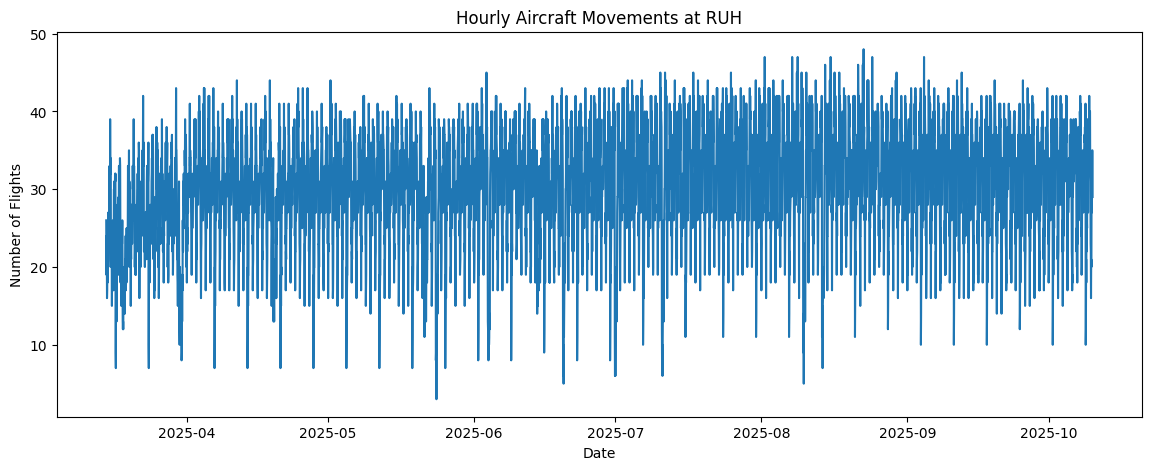

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    hourly_traffic['hour'],
    hourly_traffic['flight_count']
)

plt.xlabel('Date')
plt.ylabel('Number of Flights')
plt.title('Hourly Aircraft Movements at RUH')
plt.show()

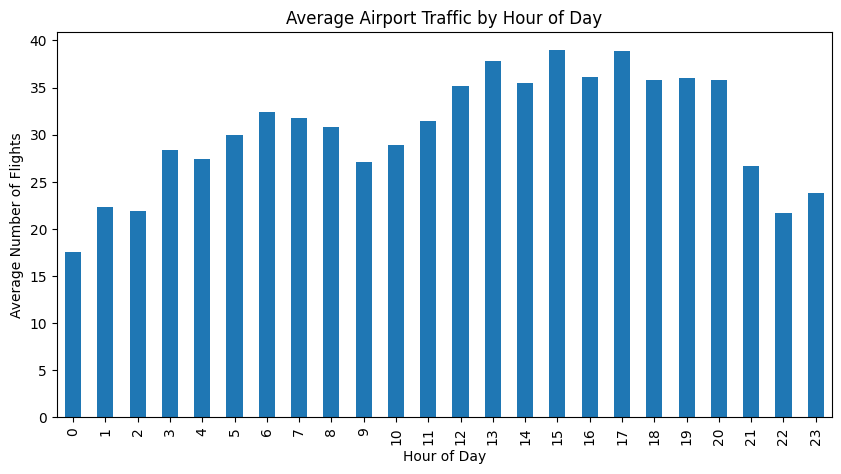

In [17]:
hourly_traffic['hour_of_day'] = hourly_traffic['hour'].dt.hour

traffic_by_hour = (
    hourly_traffic
    .groupby('hour_of_day')['flight_count']
    .mean()
)

traffic_by_hour.plot(kind='bar', figsize=(10, 5))

plt.xlabel('Hour of Day')
plt.ylabel('Average Number of Flights')
plt.title('Average Airport Traffic by Hour of Day')
plt.show()

the raw dataset has enough structure that we should not reduce it immediately to only flight_count.

A few observations before the next cells:

209 days is decent short-term coverage, but not enough for annual seasonality.
Arrivals/departures are almost perfectly balanced: 49% vs 51%.
Hourly traffic varies from 3 to 48, with a mean around 30.5. So there is meaningful variation for forecasting/pressure detection.
We have 68 airlines, 48 aircraft models, and 5 terminals — potentially useful operational-state information.
status is probably weak: ~84% is Unknown, so I wouldn't build an important feature around it yet.
origin_airport_name = 1 actually makes sense for departures: RUH is always the origin. For arrivals, destination should similarly be RUH. We need to handle route information based on flight_type, rather than treating origin/destination independently.

The next thing I want to know is: what does a busy hour actually look like compared with a normal hour?

In [18]:
movement_counts = (
    flights
    .groupby(['hour', 'flight_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

movement_counts['flight_count'] = (
    movement_counts['arrival'] +
    movement_counts['departure']
)

display(movement_counts.head())

display(
    movement_counts[
        ['arrival', 'departure', 'flight_count']
    ].describe()
)

flight_type,hour,arrival,departure,flight_count
0,2025-03-14 21:00:00+00:00,14,12,26
1,2025-03-14 22:00:00+00:00,13,6,19
2,2025-03-14 23:00:00+00:00,11,13,24
3,2025-03-15 00:00:00+00:00,16,6,22
4,2025-03-15 01:00:00+00:00,6,10,16


flight_type,arrival,departure,flight_count
count,5028.000000,5028.000000,5028.000000
mean,14.927605,15.563246,30.490851
std,5.056940,4.594322,7.327223
min,0.000000,0.000000,3.000000
25%,12.000000,13.000000,26.000000
50%,15.000000,16.000000,31.000000
75%,19.000000,19.000000,36.000000
max,26.000000,29.000000,48.000000


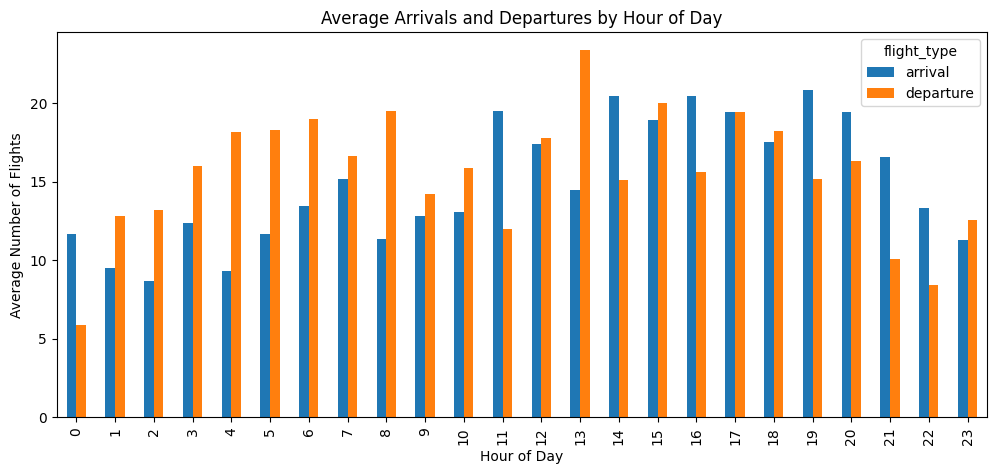

In [19]:
movement_counts['hour_of_day'] = movement_counts['hour'].dt.hour

hourly_pattern = (
    movement_counts
    .groupby('hour_of_day')[['arrival', 'departure']]
    .mean()
)

hourly_pattern.plot(
    kind='bar',
    figsize=(12, 5)
)

plt.xlabel('Hour of Day')
plt.ylabel('Average Number of Flights')
plt.title('Average Arrivals and Departures by Hour of Day')
plt.show()

In [20]:
terminal_activity = (
    flights
    .groupby(['hour', 'movement.terminal'])
    .size()
    .unstack(fill_value=0)
)

terminal_activity.columns = [
    f'terminal_{col}_count'
    for col in terminal_activity.columns
]

terminal_activity = terminal_activity.reset_index()

display(terminal_activity.head())

,hour,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count
0,2025-03-14 21:00:00+00:00,5,2,1,4,14
1,2025-03-14 22:00:00+00:00,2,0,5,1,11
2,2025-03-14 23:00:00+00:00,3,0,5,6,10
3,2025-03-15 00:00:00+00:00,3,0,8,3,8
4,2025-03-15 01:00:00+00:00,0,0,5,1,10


In [21]:
airline_activity = (
    flights
    .groupby('hour')
    .agg(
        unique_airlines=('airline.name', 'nunique')
    )
    .reset_index()
)

display(airline_activity.head())

display(
    airline_activity['unique_airlines'].describe()
)

,hour,unique_airlines
0,2025-03-14 21:00:00+00:00,10
1,2025-03-14 22:00:00+00:00,9
2,2025-03-14 23:00:00+00:00,11
3,2025-03-15 00:00:00+00:00,11
4,2025-03-15 01:00:00+00:00,8


,unique_airlines
count,5028.000000
mean,9.321002
std,1.879390
min,3.000000
25%,8.000000
50%,9.000000
75%,11.000000
max,17.000000


In [22]:
aircraft_activity = (
    flights
    .groupby('hour')
    .agg(
        unique_aircraft_models=('aircraft.model', 'nunique')
    )
    .reset_index()
)

display(aircraft_activity.head())

display(
    aircraft_activity['unique_aircraft_models'].describe()
)

,hour,unique_aircraft_models
0,2025-03-14 21:00:00+00:00,8
1,2025-03-14 22:00:00+00:00,9
2,2025-03-14 23:00:00+00:00,11
3,2025-03-15 00:00:00+00:00,5
4,2025-03-15 01:00:00+00:00,7


,unique_aircraft_models
count,5028.000000
mean,8.470764
std,2.287071
min,2.000000
25%,7.000000
50%,8.000000
75%,10.000000
max,16.000000


build one EDA table

In [23]:
airport_state = (
    movement_counts[
        ['hour', 'arrival', 'departure', 'flight_count']
    ]
    .merge(
        terminal_activity,
        on='hour',
        how='left'
    )
    .merge(
        airline_activity,
        on='hour',
        how='left'
    )
    .merge(
        aircraft_activity,
        on='hour',
        how='left'
    )
)

display(airport_state.head())

print("Shape:", airport_state.shape)

,hour,arrival,departure,flight_count,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,unique_aircraft_models
0,2025-03-14 21:00:00+00:00,14,12,26,5,2,1,4,14,10,8
1,2025-03-14 22:00:00+00:00,13,6,19,2,0,5,1,11,9,9
2,2025-03-14 23:00:00+00:00,11,13,24,3,0,5,6,10,11,11
3,2025-03-15 00:00:00+00:00,16,6,22,3,0,8,3,8,11,5
4,2025-03-15 01:00:00+00:00,6,10,16,0,0,5,1,10,8,7


Shape: (5028, 11)


In [24]:
correlation = (
    airport_state
    .drop(columns='hour')
    .corr()['flight_count']
    .sort_values(ascending=False)
)

display(correlation)

,flight_count
flight_count,1.000000
terminal_5_count,0.831168
arrival,0.784721
departure,0.731106
unique_aircraft_models,0.654391
terminal_4_count,0.617648
terminal_1_count,0.598985
unique_airlines,0.448864
terminal_3_count,0.284225
terminal_2_count,0.095865


In [25]:
airport_state['traffic_group'] = pd.qcut(
    airport_state['flight_count'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

profile = (
    airport_state
    .groupby('traffic_group', observed=True)
    .mean(numeric_only=True)
    .round(2)
)

display(profile)

,arrival,departure,flight_count,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,unique_aircraft_models
traffic_group,,,,,,,,,,
Low,9.92,11.04,20.96,2.61,0.61,4.19,2.44,11.00,8.47,6.52
Medium,13.79,15.24,29.03,4.70,0.88,3.91,4.08,15.26,9.01,8.12
High,16.97,17.05,34.02,5.31,1.06,4.36,4.83,18.26,9.61,9.21
Very High,19.75,19.62,39.37,6.32,0.61,5.48,6.41,20.39,10.34,10.33


In [26]:
busiest_hours = (
    airport_state
    .sort_values('flight_count', ascending=False)
    .head(20)
)

display(busiest_hours)

,hour,arrival,departure,flight_count,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,unique_aircraft_models,traffic_group
3860,2025-08-22 17:00:00+00:00,23,25,48,13,0,7,3,25,14,13,Very High
3496,2025-08-07 13:00:00+00:00,19,28,47,5,1,9,11,21,10,13,Very High
3904,2025-08-24 13:00:00+00:00,18,29,47,6,0,9,11,21,9,12,Very High
4168,2025-09-04 13:00:00+00:00,21,26,47,7,1,9,8,22,11,15,Very High
3692,2025-08-15 17:00:00+00:00,23,24,47,13,0,7,3,24,14,12,Very High
3524,2025-08-08 17:00:00+00:00,23,24,47,13,0,7,3,24,14,14,Very High
3356,2025-08-01 17:00:00+00:00,24,23,47,14,0,7,3,23,14,15,Very High
3832,2025-08-21 13:00:00+00:00,20,26,46,4,1,8,11,22,10,9,Very High
3664,2025-08-14 13:00:00+00:00,19,27,46,4,1,9,12,20,10,12,Very High
3856,2025-08-22 13:00:00+00:00,19,27,46,4,2,9,10,21,13,10,Very High


check average traffic by day of week × hour:

In [27]:
airport_state['day_of_week'] = airport_state['hour'].dt.day_name()
airport_state['hour_of_day'] = airport_state['hour'].dt.hour

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

traffic_pattern = (
    airport_state
    .groupby(['day_of_week', 'hour_of_day'])['flight_count']
    .mean()
    .unstack()
    .reindex(day_order)
)

display(traffic_pattern.round(1))

hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,17.6,21.2,19.7,29.1,28.2,32.5,35.2,35.7,30.9,28.2,...,35.6,38.7,36.3,39.1,35.0,37.5,37.8,31.0,22.4,25.0
Tuesday,18.6,24.0,20.7,27.3,25.2,28.2,28.8,30.9,29.8,26.4,...,36.0,39.7,36.1,38.1,36.4,35.4,34.5,28.0,23.3,23.2
Wednesday,18.4,18.9,22.8,29.6,28.4,31.1,32.8,31.0,28.1,26.5,...,34.7,37.4,35.3,37.6,34.6,36.5,39.3,22.1,20.4,24.1
Thursday,18.3,24.5,21.9,26.7,27.0,29.8,32.1,32.6,32.3,26.4,...,37.4,40.8,37.8,39.8,38.3,35.6,33.1,30.0,22.0,21.8
Friday,16.1,20.1,21.1,28.5,28.5,31.2,35.2,29.5,32.2,27.8,...,34.5,40.7,37.1,40.6,34.1,35.1,38.3,27.4,24.0,25.8
Saturday,16.4,24.8,24.4,27.9,26.0,26.6,31.3,33.0,30.9,27.2,...,35.4,36.7,34.0,39.4,36.2,35.5,33.8,31.1,22.7,25.6
Sunday,17.4,22.6,22.4,29.8,28.8,30.0,31.6,29.6,31.5,26.8,...,34.9,38.8,36.1,37.8,35.7,36.1,33.6,17.1,17.2,21.0


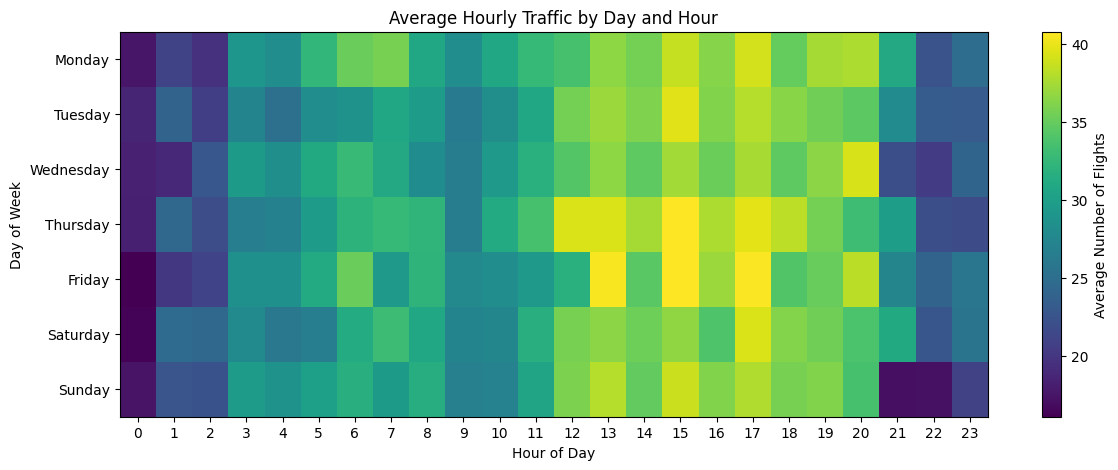

In [28]:
plt.figure(figsize=(14, 5))

plt.imshow(
    traffic_pattern,
    aspect='auto'
)

plt.colorbar(label='Average Number of Flights')

plt.xticks(
    range(24),
    range(24)
)

plt.yticks(
    range(len(day_order)),
    day_order
)

plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Average Hourly Traffic by Day and Hour')

plt.show()

In [29]:
temp = airport_state.copy()

temp['lag_1h'] = temp['flight_count'].shift(1)
temp['lag_24h'] = temp['flight_count'].shift(24)
temp['lag_168h'] = temp['flight_count'].shift(168)

print(
    temp[
        ['flight_count', 'lag_1h', 'lag_24h', 'lag_168h']
    ].corr()['flight_count']
)

flight_count    1.000000
lag_1h          0.731600
lag_24h         0.712488
lag_168h        0.840126
Name: flight_count, dtype: float64


////////////////////////////

In [30]:
flights['route_airport'] = np.where(
    flights['flight_type'] == 'departure',
    flights['destination_airport_name'],
    flights['origin_airport_name']
)

print("Unique connected airports:", flights['route_airport'].nunique())

display(
    flights['route_airport']
    .value_counts()
    .head(15)
)

Unique connected airports: 121


,count
route_airport,
Riyadh,75056
Jeddah,14377
Dubai,6250
Cairo,5212
Abha,4379
Ad Dammam,3895
Medina,3352
Jazan,2716
Tabuk,2206


In [31]:
print(
    "Missing route airports:",
    flights['route_airport'].isna().sum()
)

print(
    "Missing percentage:",
    round(flights['route_airport'].isna().mean() * 100, 2),
    "%"
)

Missing route airports: 0
Missing percentage: 0.0 %


In [32]:
route_activity = (
    flights
    .groupby('hour')
    .agg(
        unique_routes=('route_airport', 'nunique')
    )
    .reset_index()
)

display(route_activity.head())

display(
    route_activity['unique_routes'].describe()
)

,hour,unique_routes
0,2025-03-14 21:00:00+00:00,10
1,2025-03-14 22:00:00+00:00,5
2,2025-03-14 23:00:00+00:00,13
3,2025-03-15 00:00:00+00:00,6
4,2025-03-15 01:00:00+00:00,10


,unique_routes
count,5028.000000
mean,12.464996
std,3.014019
min,1.000000
25%,11.000000
50%,13.000000
75%,15.000000
max,23.000000


In [33]:
airport_state = airport_state.merge(
    route_activity,
    on='hour',
    how='left'
)

print(
    airport_state[
        ['flight_count', 'unique_routes']
    ].corr()
)

display(
    airport_state[
        ['flight_count', 'unique_routes']
    ].describe()
)

               flight_count  unique_routes
flight_count       1.000000       0.677334
unique_routes      0.677334       1.000000


,flight_count,unique_routes
count,5028.000000,5028.000000
mean,30.490851,12.464996
std,7.327223,3.014019
min,3.000000,1.000000
25%,26.000000,11.000000
50%,31.000000,13.000000
75%,36.000000,15.000000
max,48.000000,23.000000


In [34]:
display(
    airport_state
    .groupby(
        'traffic_group',
        observed=True
    )[
        [
            'flight_count',
            'unique_routes',
            'unique_airlines',
            'unique_aircraft_models'
        ]
    ]
    .mean()
    .round(2)
)

,flight_count,unique_routes,unique_airlines,unique_aircraft_models
traffic_group,,,,
Low,20.96,9.63,8.47,6.52
Medium,29.03,12.48,9.01,8.12
High,34.02,13.44,9.61,9.21
Very High,39.37,14.73,10.34,10.33


#EDA for the weather dataset

In [35]:
import io

url = "https://datasource.kapsarc.org/api/explore/v2.1/catalog/datasets/saudi-hourly-weather-data/exports/csv"

params = {
    "where": "station_id=40437099999"
}

response = requests.get(url, params=params)
response.raise_for_status()

weather = pd.read_csv(
    io.StringIO(response.text),
    sep=";"
)

print("Shape:", weather.shape)

print("\nColumns:")
print(weather.columns.tolist())

display(weather.head())

Shape: (52024, 33)

Columns:
['year', 'station_country', 'station_name', 'station_id', 'observation_date', 'elevation', 'wind_direction_angle', 'wind_direction_angle_units', 'wind_direction_quality', 'wind_type', 'wind_speed_rate', 'wind_speed_rate_units', 'wind_speed_quality', 'sky_ceiling_height', 'sky_ceiling_height_units', 'sky_ceiling_quality', 'sky_ceiling_determination', 'sky_cavok', 'visibility_distance', 'visibility_distance_units', 'visibility_distance_quality', 'visibility_variability', 'visibility_variability_quality', 'air_temperature', 'air_temperature_units', 'air_temperature_quality', 'air_temperature_dew_point', 'air_temperature_dew_point_units', 'air_temperature_dew_point_quality', 'atmospheric_sea_level_pressure', 'atmospheric_sea_level_pressure_units', 'atmospheric_sea_level_pressure_quality', 'geopoint']


,year,station_country,station_name,station_id,observation_date,elevation,wind_direction_angle,wind_direction_angle_units,wind_direction_quality,wind_type,...,air_temperature,air_temperature_units,air_temperature_quality,air_temperature_dew_point,air_temperature_dew_point_units,air_temperature_dew_point_quality,atmospheric_sea_level_pressure,atmospheric_sea_level_pressure_units,atmospheric_sea_level_pressure_quality,geopoint
0,2025,SA,KING KHALED INTL,40437099999,2025-08-24T21:00:00+00:00,624.53,999,ANGULAR DEGREES,Passed gross limits check if element is present,Calm,...,31.9,DEGREES CELSIUS,Passed all quality control checks,-2.0,DEGREES CELSIUS,Passed all quality control checks,999.8,HECTOPASCALS,Passed all quality control checks,"24.957639999999998, 46.698776"
1,2025,SA,KING KHALED INTL,40437099999,2025-08-24T21:00:00+00:00,624.53,999,ANGULAR DEGREES,Passed gross limits check if element is present,Calm,...,32.0,DEGREES CELSIUS,Passed all quality control checks,-2.0,DEGREES CELSIUS,Passed all quality control checks,9999.9,HECTOPASCALS,Passed gross limits check if element is present,"24.957639999999998, 46.698776"
2,2025,SA,KING KHALED INTL,40437099999,2025-08-24T20:00:00+00:00,624.53,999,ANGULAR DEGREES,Passed gross limits check if element is present,Calm,...,33.0,DEGREES CELSIUS,Passed all quality control checks,-1.0,DEGREES CELSIUS,Passed all quality control checks,9999.9,HECTOPASCALS,Passed gross limits check if element is present,"24.957639999999998, 46.698776"
3,2025,SA,KING KHALED INTL,40437099999,2025-08-24T19:00:00+00:00,624.53,310,ANGULAR DEGREES,Passed all quality control checks,Normal,...,35.0,DEGREES CELSIUS,Passed all quality control checks,-2.0,DEGREES CELSIUS,Passed all quality control checks,9999.9,HECTOPASCALS,Passed gross limits check if element is present,"24.957639999999998, 46.698776"
4,2025,SA,KING KHALED INTL,40437099999,2025-08-24T18:00:00+00:00,624.53,350,ANGULAR DEGREES,Passed all quality control checks,Normal,...,35.0,DEGREES CELSIUS,Passed all quality control checks,-2.0,DEGREES CELSIUS,Passed all quality control checks,9999.9,HECTOPASCALS,Passed gross limits check if element is present,"24.957639999999998, 46.698776"


In [36]:
weather['observation_date'] = pd.to_datetime(weather['observation_date'])

print("Date range:")
print(weather['observation_date'].min())
print(weather['observation_date'].max())

print("\nUnique timestamps:")
print(weather['observation_date'].nunique())

print("\nRecords per timestamp:")
print(weather.groupby('observation_date').size().describe())

Date range:
2021-01-01 00:00:00+00:00
2025-08-24 21:00:00+00:00

Unique timestamps:
39215

Records per timestamp:
count    39215.000000
mean         1.326635
std          0.468989
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          2.000000
dtype: float64


In [37]:
weather_features = [
    'air_temperature',
    'wind_speed_rate',
    'wind_direction_angle',
    'visibility_distance',
    'sky_ceiling_height',
    'air_temperature_dew_point',
    'atmospheric_sea_level_pressure'
]

print("Missing values:")
print(weather[weather_features].isna().sum())

print("\nSummary:")
display(weather[weather_features].describe())

Missing values:
air_temperature                   0
wind_speed_rate                   0
wind_direction_angle              0
visibility_distance               0
sky_ceiling_height                0
air_temperature_dew_point         0
atmospheric_sea_level_pressure    0
dtype: int64

Summary:


,air_temperature,wind_speed_rate,wind_direction_angle,visibility_distance,sky_ceiling_height,air_temperature_dew_point,atmospheric_sea_level_pressure
count,52024.000000,52024.000000,52024.000000,52024.000000,52024.000000,52024.000000,52024.000000
mean,27.970398,2.733187,254.487217,9365.907831,83073.557262,3.196033,7776.106610
std,10.457472,1.819993,263.239340,6369.829266,34640.714437,23.070042,3879.202731
min,1.900000,0.000000,10.000000,0.000000,0.000000,-17.000000,992.300000
25%,20.000000,1.500000,90.000000,9900.000000,99999.000000,-1.000000,9999.900000
50%,28.800000,2.600000,170.000000,9900.000000,99999.000000,3.000000,9999.900000
75%,35.900000,3.600000,320.000000,9999.000000,99999.000000,7.000000,9999.900000
max,999.900000,15.400000,999.000000,999999.000000,99999.000000,999.900000,9999.900000


In [38]:
sentinel_counts = {
    'air_temperature': (weather['air_temperature'] >= 999).sum(),
    'wind_direction_angle': (weather['wind_direction_angle'] == 999).sum(),
    'visibility_distance': (weather['visibility_distance'] >= 999999).sum(),
    'sky_ceiling_height': (weather['sky_ceiling_height'] == 99999).sum(),
    'air_temperature_dew_point': (weather['air_temperature_dew_point'] >= 999).sum(),
    'atmospheric_sea_level_pressure': (weather['atmospheric_sea_level_pressure'] >= 9999).sum()
}

sentinel_summary = pd.DataFrame({
    'count': sentinel_counts
})

sentinel_summary['percentage'] = (
    sentinel_summary['count'] / len(weather) * 100
).round(2)

display(sentinel_summary)

,count,percentage
air_temperature,1,0.00
wind_direction_angle,4907,9.43
visibility_distance,2,0.00
sky_ceiling_height,41863,80.47
air_temperature_dew_point,26,0.05
atmospheric_sea_level_pressure,39156,75.27


In [39]:
weather_project = weather[
    (weather['observation_date'] >= '2025-03-14') &
    (weather['observation_date'] <= '2025-08-24 21:00:00+00:00')
].copy()

print("Project-period records:", len(weather_project))
print("Unique timestamps:", weather_project['observation_date'].nunique())

sentinel_project = {
    'air_temperature': (weather_project['air_temperature'] >= 999).sum(),
    'wind_direction_angle': (weather_project['wind_direction_angle'] == 999).sum(),
    'visibility_distance': (weather_project['visibility_distance'] >= 999999).sum(),
    'sky_ceiling_height': (weather_project['sky_ceiling_height'] == 99999).sum(),
    'air_temperature_dew_point': (weather_project['air_temperature_dew_point'] >= 999).sum(),
    'atmospheric_sea_level_pressure': (weather_project['atmospheric_sea_level_pressure'] >= 9999).sum()
}

sentinel_project = pd.DataFrame({
    'count': sentinel_project
})

sentinel_project['percentage'] = (
    sentinel_project['count'] / len(weather_project) * 100
).round(2)

display(sentinel_project)

Project-period records: 5219
Unique timestamps: 3928


,count,percentage
air_temperature,0,0.00
wind_direction_angle,266,5.10
visibility_distance,0,0.00
sky_ceiling_height,4436,85.00
air_temperature_dew_point,0,0.00
atmospheric_sea_level_pressure,3924,75.19


In [40]:
weather_clean = weather_project.copy()

# Replace sentinel values with NaN
weather_clean.loc[
    weather_clean['air_temperature'] >= 999,
    'air_temperature'
] = np.nan

weather_clean.loc[
    weather_clean['wind_direction_angle'] == 999,
    'wind_direction_angle'
] = np.nan

weather_clean.loc[
    weather_clean['visibility_distance'] >= 999999,
    'visibility_distance'
] = np.nan

weather_clean.loc[
    weather_clean['air_temperature_dew_point'] >= 999,
    'air_temperature_dew_point'
] = np.nan

# Focus on the useful weather features
useful_weather = [
    'air_temperature',
    'wind_speed_rate',
    'wind_direction_angle',
    'visibility_distance',
    'air_temperature_dew_point'
]

display(weather_clean[useful_weather].describe())

,air_temperature,wind_speed_rate,wind_direction_angle,visibility_distance,air_temperature_dew_point
count,5219.000000,5219.000000,4953.000000,5219.000000,5219.000000
mean,33.670052,3.009600,206.482940,9364.232037,-3.233186
std,7.021982,1.741907,119.924698,1713.325435,4.826646
min,10.700000,0.000000,10.000000,0.000000,-15.000000
25%,29.000000,1.500000,100.000000,9900.000000,-7.000000
50%,34.000000,2.600000,260.000000,9900.000000,-4.000000
75%,39.000000,4.100000,310.000000,9999.000000,-1.000000
max,46.000000,14.400000,360.000000,10000.000000,20.000000


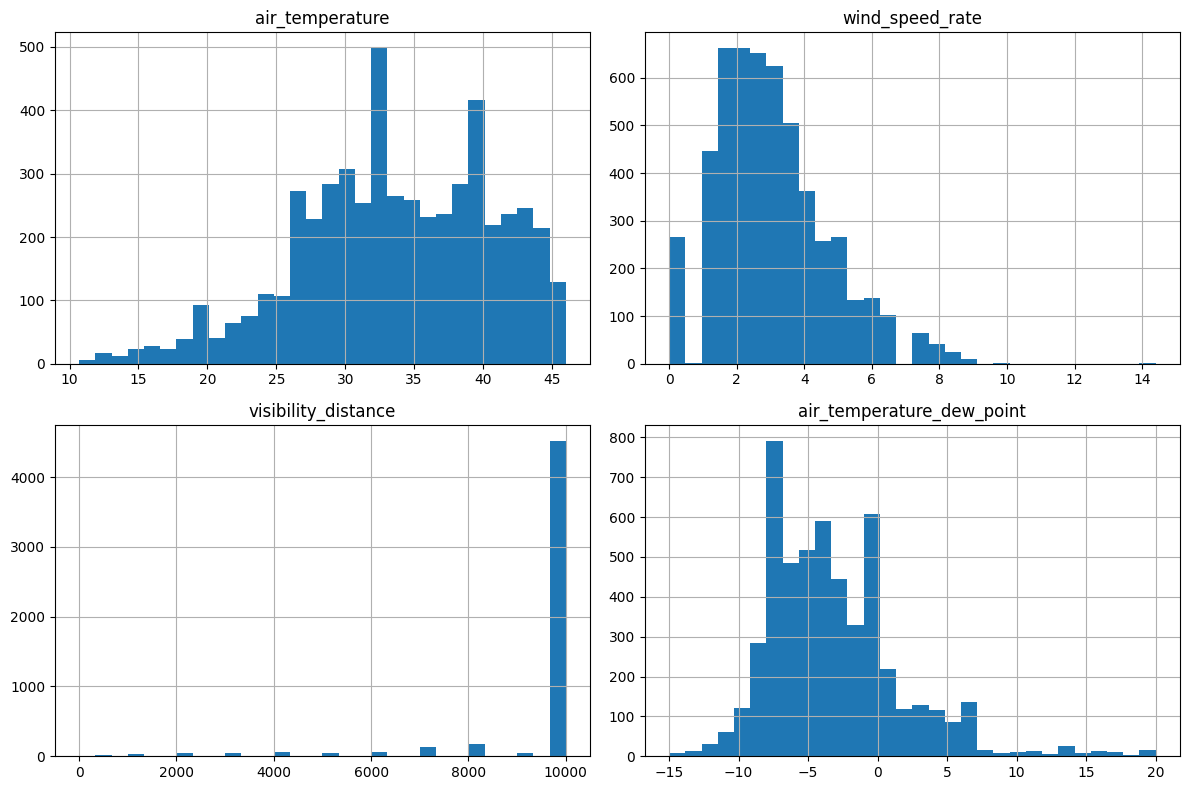

In [41]:

features_to_plot = [
    'air_temperature',
    'wind_speed_rate',
    'visibility_distance',
    'air_temperature_dew_point'
]

weather_clean[features_to_plot].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [42]:
weather_features = [
    'air_temperature',
    'wind_speed_rate',
    'wind_direction_angle',
    'visibility_distance',
    'air_temperature_dew_point'
]

weather_clean['hour'] = weather_clean['observation_date'].dt.floor('h')

weather_hourly = (
    weather_clean
    .groupby('hour')[weather_features]
    .mean()
    .reset_index()
)

print("Hourly weather shape:", weather_hourly.shape)
print(
    "Date range:",
    weather_hourly['hour'].min(),
    "to",
    weather_hourly['hour'].max()
)

print("\nMissing values:")
print(weather_hourly.isna().sum())

Hourly weather shape: (3889, 6)
Date range: 2025-03-14 00:00:00+00:00 to 2025-08-24 21:00:00+00:00

Missing values:
hour                           0
air_temperature                0
wind_speed_rate                0
wind_direction_angle         200
visibility_distance            0
air_temperature_dew_point      0
dtype: int64


#Flight and weather relationship analysis

In [43]:
combined_df = pd.merge(
    hourly_traffic,
    weather_hourly,
    on='hour',
    how='inner'
)

print("Combined shape:", combined_df.shape)

print(
    "Date range:",
    combined_df['hour'].min(),
    "to",
    combined_df['hour'].max()
)

display(combined_df.head())

Combined shape: (3868, 8)
Date range: 2025-03-14 21:00:00+00:00 to 2025-08-24 21:00:00+00:00


,hour,flight_count,hour_of_day,air_temperature,wind_speed_rate,wind_direction_angle,visibility_distance,air_temperature_dew_point
0,2025-03-14 21:00:00+00:00,26,21,18.9,1.5,360.0,9950.0,-1.0
1,2025-03-14 22:00:00+00:00,19,22,18.0,1.0,310.0,9900.0,0.0
2,2025-03-14 23:00:00+00:00,24,23,17.0,0.0,NaN,9900.0,1.0
3,2025-03-15 00:00:00+00:00,22,0,16.1,1.0,270.0,9950.0,1.0
4,2025-03-15 01:00:00+00:00,16,1,16.0,1.0,280.0,9900.0,0.0


In [44]:
weather_cols = [
    'air_temperature',
    'wind_speed_rate',
    'visibility_distance',
    'air_temperature_dew_point'
]

correlations = combined_df[
    ['flight_count'] + weather_cols
].corr()['flight_count'].sort_values(ascending=False)

print("Correlation with flight_count:")
print(correlations)

Correlation with flight_count:
flight_count                 1.000000
air_temperature              0.501713
wind_speed_rate              0.279723
visibility_distance          0.049100
air_temperature_dew_point   -0.115718
Name: flight_count, dtype: float64


In [45]:
print("Visibility:")
print(combined_df['visibility_distance'].quantile(
    [0, 0.01, 0.05, 0.10, 0.25, 0.50]
))

print("\nWind speed:")
print(combined_df['wind_speed_rate'].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
))

Visibility:
0.00     400.0
0.01    1500.0
0.05    5675.0
0.10    8000.0
0.25    9900.0
0.50    9900.0
Name: visibility_distance, dtype: float64

Wind speed:
0.50     2.6
0.75     4.1
0.90     5.1
0.95     6.2
0.99     7.7
1.00    10.3
Name: wind_speed_rate, dtype: float64


In [46]:
low_visibility = combined_df['visibility_distance'] <= 5675
high_wind = combined_df['wind_speed_rate'] >= 6.2

print("Average flight count")

print("\nLow visibility hours:",
      combined_df.loc[low_visibility, 'flight_count'].mean())

print("Normal visibility hours:",
      combined_df.loc[~low_visibility, 'flight_count'].mean())

print("\nHigh wind hours:",
      combined_df.loc[high_wind, 'flight_count'].mean())

print("Normal wind hours:",
      combined_df.loc[~high_wind, 'flight_count'].mean())

print("\nNumber of low visibility hours:", low_visibility.sum())
print("Number of high wind hours:", high_wind.sum())

Average flight count

Low visibility hours: 28.304123711340207
Normal visibility hours: 30.295862819814914

High wind hours: 33.24909747292419
Normal wind hours: 29.960456697298802

Number of low visibility hours: 194
Number of high wind hours: 277


# EDA Analysis and Key Findings

The exploratory analysis provided several insights that will guide the next stages of the project.

### Flight Data

- The flight dataset contains 153,308 records covering approximately seven months of operations at King Khalid International Airport.
- Arrivals and departures are relatively balanced, representing approximately 49% and 51% of the records respectively.
- Hourly traffic varies considerably, ranging from 3 to 48 aircraft movements per hour, with an average of approximately 30 movements.
- Traffic follows clear temporal patterns across the hour of day and day of week.
- Weekly traffic patterns are particularly strong, suggesting that the airport operates according to a highly repetitive flight schedule.
- Higher-traffic periods are also associated with greater terminal activity and greater diversity in airlines and aircraft types. This suggests that airport activity can be represented by more than total flight count alone.
- Initial route analysis showed useful route diversity, but the origin/destination fields require further validation before route-based features are used.

### Weather Data

- The KKIA weather dataset contains 52,024 observations from January 2021 to August 2025, with multiple observations recorded for some timestamps.
- During the period overlapping with the flight dataset, temperature, wind speed, visibility, and dew point have good data availability.
- Wind direction has a relatively small amount of missing information after invalid values are removed.
- Cloud ceiling and atmospheric pressure contain a high proportion of unavailable or sentinel values (approximately 85% and 75% during the project period), making them weak candidates for the initial model.
- Temperature, wind speed, visibility, and dew point show sufficient variation to be considered as potential external forecasting features.
- Low-visibility and high-wind conditions occur in the dataset, providing an opportunity to investigate whether unusual weather conditions contribute additional predictive information.

### Combined Flight and Weather Data

- After hourly aggregation and alignment, 3,868 hourly observations contain both flight traffic and weather information, covering March 14 to August 24, 2025.
- Initial correlations show that temperature and wind speed are associated with hourly traffic, while visibility and dew point have weaker direct linear relationships.
- Hours in the lowest 5% of visibility had an average of approximately 28.3 movements, compared with 30.3 during other hours.
- Hours in the highest 5% of wind speed had an average of approximately 33.2 movements, compared with 30.0 during other hours.
- These relationships should not be interpreted as causal effects because both airport traffic and weather vary with time and season.

### Implications for the Project

The EDA suggests that airport traffic is strongly structured by recurring temporal patterns, particularly the weekly flight schedule. Therefore, historical traffic and time-based features are likely to provide a strong forecasting baseline.

Weather can be incorporated as an external source of information, particularly temperature, wind, visibility, and dew point. However, its incremental predictive value should be evaluated against a traffic-only baseline rather than assumed in advance.

The flight data also contains information beyond total aircraft movements, including arrivals, departures, terminal activity, airline diversity, and aircraft diversity. These variables provide an opportunity to represent the airport as a richer operational state rather than relying only on total hourly traffic.

These findings will guide the feature engineering, forecasting horizon, operational-pressure definition, and model design in the next stage of the project.

# Data Preparation for KKIA dataset

## Duplicate Investigation

The Initial EDA identified 2,789 potential duplicate flight records based on
`flight_number`, `movement.scheduledTime.utc`, and `flight_type`.

Before removing any records, these potential duplicates were investigated to
determine whether they represented true duplicate flight events or distinct flights.

In [47]:
# Identify potential duplicate flight records

duplicate_cols = [
    'flight_number',
    'movement.scheduledTime.utc',
    'flight_type'
]

potential_duplicates = (
    flights[
        flights.duplicated(subset=duplicate_cols, keep=False)
    ]
    .sort_values(duplicate_cols)
)

print("Rows involved in duplicate groups:", len(potential_duplicates))
print(
    "Duplicate groups:",
    potential_duplicates.groupby(duplicate_cols).ngroups
)

Rows involved in duplicate groups: 5578
Duplicate groups: 2789


In [48]:
# Check for exact duplicate rows

exact_duplicate_cols = [
    col for col in flights.columns
    if col != 'movement.quality'
]

exact_duplicates = flights.duplicated(
    subset=exact_duplicate_cols,
    keep=False
)

print("Rows involved in exact duplicates:", exact_duplicates.sum())

print(
    "Extra exact duplicate rows:",
    flights.duplicated(
        subset=exact_duplicate_cols
    ).sum()
)

Rows involved in exact duplicates: 0
Extra exact duplicate rows: 0


In [49]:
# Identify which fields vary within potential duplicate groups

variation_by_column = {}

for col in flights.columns:
    if col not in duplicate_cols and col != 'movement.quality':
        counts = (
            potential_duplicates
            .groupby(duplicate_cols)[col]
            .nunique(dropna=False)
        )
        variation_by_column[col] = (counts > 1).sum()

variation_by_column = (
    pd.Series(variation_by_column)
    .sort_values(ascending=False)
)

display(variation_by_column[variation_by_column > 0])

,0
aircraft.model,2510
aircraft.modeS,1545
aircraft.reg,1229


### Duplicate Handling Decision

The investigation showed that records within the 2,789 potential duplicate groups
share the same core flight information. Differences were found only in aircraft
metadata: `aircraft.model`, `aircraft.modeS`, and `aircraft.reg`.

Since the project models hourly flight activity, counting both records would
double-count the same scheduled flight. Therefore, each flight is represented once
using `flight_number`, `movement.scheduledTime.utc`, and `flight_type` as the
flight identifier.

When duplicate records exist, the record with more complete information is retained.
The original `flights` DataFrame is kept unchanged.

In [50]:
# Create a clean copy and retain the most complete record

flights_clean = flights.copy()

flights_clean['missing_count'] = flights_clean.isna().sum(axis=1)

flights_clean = (
    flights_clean
    .sort_values('missing_count')
    .drop_duplicates(
        subset=duplicate_cols,
        keep='first'
    )
    .drop(columns='missing_count')
    .reset_index(drop=True)
)

In [51]:
# Validate duplicate cleaning

print("Original rows:", len(flights))
print("Clean rows:", len(flights_clean))
print("Rows removed:", len(flights) - len(flights_clean))

print(
    "Remaining duplicate flight identifiers:",
    flights_clean.duplicated(subset=duplicate_cols).sum()
)

assert len(flights_clean) == 150519
assert flights_clean.duplicated(subset=duplicate_cols).sum() == 0
assert len(flights) == 153308

print("\nOriginal date range:")
print(
    flights['movement.scheduledTime.utc'].min(),
    "to",
    flights['movement.scheduledTime.utc'].max()
)

print("\nClean date range:")
print(
    flights_clean['movement.scheduledTime.utc'].min(),
    "to",
    flights_clean['movement.scheduledTime.utc'].max()
)

print("\nDuplicate cleaning validation passed.")

Original rows: 153308
Clean rows: 150519
Rows removed: 2789
Remaining duplicate flight identifiers: 0

Original date range:
2025-03-14 21:01:00+00:00 to 2025-10-10 08:45:00+00:00

Clean date range:
2025-03-14 21:01:00+00:00 to 2025-10-10 08:45:00+00:00

Duplicate cleaning validation passed.


### Duplicate Cleaning Result

A total of 2,789 duplicate flight records were removed using
`flight_number`, `movement.scheduledTime.utc`, and `flight_type`
as the flight identifier.

For duplicate groups, the most complete record was retained.
After cleaning, the dataset contains 150,519 flight records with
no remaining duplicate flight identifiers, while the original date range
was preserved.

## Hourly Dataset Validation

The hourly traffic dataset is rebuilt from the cleaned flight records.
The timeline is then checked for missing hourly observations before feature engineering.

In [52]:
# Rebuild hourly traffic from cleaned flight data

flights_clean['hour'] = (
    flights_clean['movement.scheduledTime.utc'].dt.floor('h')
)

hourly_traffic_clean = (
    flights_clean
    .groupby('hour')
    .size()
    .reset_index(name='flight_count')
    .sort_values('hour')
    .reset_index(drop=True)
)

print("Hourly observations:", len(hourly_traffic_clean))
print(
    "Date range:",
    hourly_traffic_clean['hour'].min(),
    "to",
    hourly_traffic_clean['hour'].max()
)

display(hourly_traffic_clean.head())

Hourly observations: 5028
Date range: 2025-03-14 21:00:00+00:00 to 2025-10-10 08:00:00+00:00


,hour,flight_count
0,2025-03-14 21:00:00+00:00,26
1,2025-03-14 22:00:00+00:00,19
2,2025-03-14 23:00:00+00:00,24
3,2025-03-15 00:00:00+00:00,22
4,2025-03-15 01:00:00+00:00,16


In [53]:
# Check for missing hours in the timeline

expected_hours = pd.date_range(
    start=hourly_traffic_clean['hour'].min(),
    end=hourly_traffic_clean['hour'].max(),
    freq='h'
)

missing_hours = expected_hours.difference(
    hourly_traffic_clean['hour']
)

print("Expected hourly observations:", len(expected_hours))
print("Actual hourly observations:", len(hourly_traffic_clean))
print("Missing hours:", len(missing_hours))

if len(missing_hours) > 0:
    display(missing_hours[:20])

Expected hourly observations: 5028
Actual hourly observations: 5028
Missing hours: 0


Hourly Dataset Validation Result

The cleaned dataset contains 5,028 consecutive hourly observations with no missing
hours in the timeline. Therefore, no hourly reindexing or gap filling is required.

The airport dataset was cleaned by removing 2,789 duplicate flight records while
retaining the most complete record for each flight event.

The final cleaned dataset contains 150,519 flight records. After hourly aggregation,
it contains 5,028 consecutive hourly observations with no missing hours.

The prepared airport traffic dataset is ready for feature engineering.

# Weather Data Preparation

Weather data was previously explored and cleaned during the Initial EDA.
This section prepares the selected weather variables for modeling and validates
their hourly coverage before integration with the airport traffic data.

In [54]:
# Select weather features for modeling

weather_features = [
    'air_temperature',
    'wind_speed_rate',
    'visibility_distance',
    'air_temperature_dew_point'
]

weather_model = weather_clean[
    ['observation_date'] + weather_features
].copy()

print("Weather records:", len(weather_model))
print("\nMissing values:")
print(weather_model[weather_features].isna().sum())

print("\nMissing percentages:")
print(
    (weather_model[weather_features].isna().mean() * 100)
    .round(2)
)

Weather records: 5219

Missing values:
air_temperature              0
wind_speed_rate              0
visibility_distance          0
air_temperature_dew_point    0
dtype: int64

Missing percentages:
air_temperature              0.0
wind_speed_rate              0.0
visibility_distance          0.0
air_temperature_dew_point    0.0
dtype: float64


Weather Missing Values Check

The selected weather features contain no missing values after the cleaning performed
during the Initial EDA. Therefore, no additional missing-value imputation is required
for these variables.

The cleaned weather data can proceed directly to hourly aggregation.

### Hourly Weather Aggregation


In [55]:
# Aggregate cleaned weather observations to hourly level

weather_model['hour'] = (
    weather_model['observation_date'].dt.floor('h')
)

weather_hourly_clean = (
    weather_model
    .groupby('hour')[weather_features]
    .mean()
    .reset_index()
    .sort_values('hour')
    .reset_index(drop=True)
)

print("Hourly weather observations:", len(weather_hourly_clean))

print(
    "Date range:",
    weather_hourly_clean['hour'].min(),
    "to",
    weather_hourly_clean['hour'].max()
)

print("\nMissing values after hourly aggregation:")
print(weather_hourly_clean.isna().sum())

display(weather_hourly_clean.head())

Hourly weather observations: 3889
Date range: 2025-03-14 00:00:00+00:00 to 2025-08-24 21:00:00+00:00

Missing values after hourly aggregation:
hour                         0
air_temperature              0
wind_speed_rate              0
visibility_distance          0
air_temperature_dew_point    0
dtype: int64


,hour,air_temperature,wind_speed_rate,visibility_distance,air_temperature_dew_point
0,2025-03-14 00:00:00+00:00,16.95,2.1,9950.0,4.0
1,2025-03-14 01:00:00+00:00,17.00,2.1,9900.0,4.0
2,2025-03-14 02:00:00+00:00,16.00,2.1,9900.0,4.0
3,2025-03-14 03:00:00+00:00,15.85,2.1,9999.5,4.0
4,2025-03-14 04:00:00+00:00,16.00,2.1,9999.0,4.0


The cleaned weather data was aggregated into 3,889 hourly observations covering
March 14 to August 24, 2025. No missing values remain in the selected weather
features after hourly aggregation.

The airport traffic data extends to October 10, 2025, while weather data is only
available through August 24, 2025. Therefore, models that include weather features
will be evaluated using the overlapping flight-weather period to ensure a fair
comparison.

In [56]:
# Check for missing hours in the weather timeline

expected_weather_hours = pd.date_range(
    start=weather_hourly_clean['hour'].min(),
    end=weather_hourly_clean['hour'].max(),
    freq='h'
)

missing_weather_hours = expected_weather_hours.difference(
    weather_hourly_clean['hour']
)

print("Expected weather hours:", len(expected_weather_hours))
print("Actual weather hours:", len(weather_hourly_clean))
print("Missing weather hours:", len(missing_weather_hours))

if len(missing_weather_hours) > 0:
    display(missing_weather_hours[:20])

Expected weather hours: 3934
Actual weather hours: 3889
Missing weather hours: 45


DatetimeIndex(['2025-03-26 02:00:00+00:00', '2025-03-27 19:00:00+00:00',
               '2025-03-27 20:00:00+00:00', '2025-03-27 21:00:00+00:00',
               '2025-03-27 22:00:00+00:00', '2025-03-27 23:00:00+00:00',
               '2025-03-28 00:00:00+00:00', '2025-03-28 01:00:00+00:00',
               '2025-03-28 02:00:00+00:00', '2025-03-28 03:00:00+00:00',
               '2025-03-28 04:00:00+00:00', '2025-03-28 14:00:00+00:00',
               '2025-03-31 16:00:00+00:00', '2025-04-28 21:00:00+00:00',
               '2025-04-28 22:00:00+00:00', '2025-05-02 02:00:00+00:00',
               '2025-05-12 18:00:00+00:00', '2025-05-27 14:00:00+00:00',
               '2025-06-02 21:00:00+00:00', '2025-06-08 11:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)

The hourly weather timeline contains 3,889 observed hours out of 3,934 expected hours,
with 45 missing hourly observations (~1.14%).

Because some missing hours occur consecutively, the gaps are investigated before
applying any filling or interpolation method.

In [57]:
# Analyze consecutive gaps in the hourly weather timeline

missing_series = pd.Series(missing_weather_hours)

gap_groups = (
    missing_series.diff().ne(pd.Timedelta(hours=1)).cumsum()
)

weather_gaps = (
    missing_series
    .groupby(gap_groups)
    .agg(['first', 'last', 'count'])
    .rename(columns={
        'first': 'gap_start',
        'last': 'gap_end',
        'count': 'missing_hours'
    })
    .reset_index(drop=True)
)

display(weather_gaps)

print("Number of gaps:", len(weather_gaps))
print("Longest gap:", weather_gaps['missing_hours'].max(), "hours")

,gap_start,gap_end,missing_hours
0,2025-03-26 02:00:00+00:00,2025-03-26 02:00:00+00:00,1
1,2025-03-27 19:00:00+00:00,2025-03-28 04:00:00+00:00,10
2,2025-03-28 14:00:00+00:00,2025-03-28 14:00:00+00:00,1
3,2025-03-31 16:00:00+00:00,2025-03-31 16:00:00+00:00,1
4,2025-04-28 21:00:00+00:00,2025-04-28 22:00:00+00:00,2
5,2025-05-02 02:00:00+00:00,2025-05-02 02:00:00+00:00,1
6,2025-05-12 18:00:00+00:00,2025-05-12 18:00:00+00:00,1
7,2025-05-27 14:00:00+00:00,2025-05-27 14:00:00+00:00,1
8,2025-06-02 21:00:00+00:00,2025-06-02 21:00:00+00:00,1
9,2025-06-08 11:00:00+00:00,2025-06-08 14:00:00+00:00,4


Number of gaps: 23
Longest gap: 10 hours


The weather timeline contains 23 missing intervals, totaling 45 hours.
Most gaps are short, although the longest continuous gap spans 10 hours.

Because weather features are used as an additional modeling experiment rather than
the core forecasting signal, missing weather hours are not interpolated at this stage.
Only hours with observed weather data will be used when constructing the
traffic-plus-weather modeling dataset.

In [58]:
# Final validation of the prepared hourly weather dataset

print("Final weather rows:", len(weather_hourly_clean))

print(
    "Date range:",
    weather_hourly_clean['hour'].min(),
    "to",
    weather_hourly_clean['hour'].max()
)

print(
    "Missing values:",
    weather_hourly_clean[weather_features].isna().sum().sum()
)

print(
    "Duplicate hours:",
    weather_hourly_clean.duplicated(subset='hour').sum()
)

Final weather rows: 3889
Date range: 2025-03-14 00:00:00+00:00 to 2025-08-24 21:00:00+00:00
Missing values: 0
Duplicate hours: 0


The final weather dataset contains 3,889 unique hourly observations from
March 14 to August 24, 2025.

The selected weather features contain no missing values or duplicate hourly
timestamps. A total of 45 hours are absent from the weather timeline and are
left unfilled to avoid introducing artificial weather observations.

The prepared weather dataset is ready for integration with airport traffic data
during the traffic-plus-weather modeling experiment.

# Feature Engineering

This section builds the model-ready dataset. Flight-based features are
rebuilt on the cleaned flight data (`flights_clean`), then merged with
temporal, lag, and rolling features. Weather is merged separately as an
additional experiment, consistent with the project plan.

## Rebuilding Flight-Based Features on Cleaned Data

The terminal, airline, aircraft, and route diversity features from the
Initial EDA were computed on the raw `flights` dataset, before duplicate
removal. They are rebuilt here on `flights_clean` so all features are
consistent with the cleaned dataset.

In [59]:
# Terminal activity
terminal_activity = (
    flights_clean
    .groupby(['hour', 'movement.terminal'])
    .size()
    .unstack(fill_value=0)
)
terminal_activity.columns = [f'terminal_{col}_count' for col in terminal_activity.columns]
terminal_activity = terminal_activity.reset_index()

# Airline diversity
airline_activity = (
    flights_clean
    .groupby('hour')
    .agg(unique_airlines=('airline.name', 'nunique'))
    .reset_index()
)

# Aircraft diversity
aircraft_activity = (
    flights_clean
    .groupby('hour')
    .agg(unique_aircraft_models=('aircraft.model', 'nunique'))
    .reset_index()
)

# Route diversity
flights_clean['route_airport'] = np.where(
    flights_clean['flight_type'] == 'departure',
    flights_clean['destination_airport_name'],
    flights_clean['origin_airport_name']
)

route_activity = (
    flights_clean
    .groupby('hour')
    .agg(unique_routes=('route_airport', 'nunique'))
    .reset_index()
)

# Arrival/departure split
movement_counts_clean = (
    flights_clean
    .groupby(['hour', 'flight_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

## Building the Base Feature Table

All flight-based features are merged into a single hourly table,
`airport_state`, using the cleaned hourly traffic as the base.

In [60]:
airport_state = (
    hourly_traffic_clean
    .merge(movement_counts_clean, on='hour', how='left')
    .merge(terminal_activity, on='hour', how='left')
    .merge(airline_activity, on='hour', how='left')
    .merge(aircraft_activity, on='hour', how='left')
    .merge(route_activity, on='hour', how='left')
)

print("Shape after merging flight-based features:", airport_state.shape)
display(airport_state.head())

Shape after merging flight-based features: (5028, 12)


,hour,flight_count,arrival,departure,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,unique_aircraft_models,unique_routes
0,2025-03-14 21:00:00+00:00,26,14,12,5,2,1,4,14,10,8,10
1,2025-03-14 22:00:00+00:00,19,13,6,2,0,5,1,11,9,9,5
2,2025-03-14 23:00:00+00:00,24,11,13,3,0,5,6,10,11,11,13
3,2025-03-15 00:00:00+00:00,22,16,6,3,0,8,3,8,11,5,6
4,2025-03-15 01:00:00+00:00,16,6,10,0,0,5,1,10,8,7,10


## Temporal Features

Hour of day and day of week are the strongest signals identified during
EDA. Cyclical encoding (sine/cosine) is used instead of raw integers, so
the model correctly treats hour 23 and hour 0 as close together.

In [61]:
airport_state['hour_of_day'] = airport_state['hour'].dt.hour
airport_state['day_of_week'] = airport_state['hour'].dt.dayofweek
airport_state['is_weekend'] = airport_state['day_of_week'].isin([4, 5]).astype(int)

airport_state['hour_sin'] = np.sin(2 * np.pi * airport_state['hour_of_day'] / 24)
airport_state['hour_cos'] = np.cos(2 * np.pi * airport_state['hour_of_day'] / 24)
airport_state['dow_sin'] = np.sin(2 * np.pi * airport_state['day_of_week'] / 7)
airport_state['dow_cos'] = np.cos(2 * np.pi * airport_state['day_of_week'] / 7)

display(airport_state[['hour', 'hour_of_day', 'day_of_week', 'is_weekend',
                        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']].head())

,hour,hour_of_day,day_of_week,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,2025-03-14 21:00:00+00:00,21,4,1,-0.707107,0.707107,-0.433884,-0.900969
1,2025-03-14 22:00:00+00:00,22,4,1,-0.500000,0.866025,-0.433884,-0.900969
2,2025-03-14 23:00:00+00:00,23,4,1,-0.258819,0.965926,-0.433884,-0.900969
3,2025-03-15 00:00:00+00:00,0,5,1,0.000000,1.000000,-0.974928,-0.222521
4,2025-03-15 01:00:00+00:00,1,5,1,0.258819,0.965926,-0.974928,-0.222521


## Lag Features

Lag features capture how current traffic relates to traffic in the recent
past and one week prior. The 168-hour (7-day) lag showed the strongest
correlation with current traffic during EDA (r = 0.84).

In [62]:
airport_state = airport_state.sort_values('hour').reset_index(drop=True)

for lag in [1, 2, 3, 24, 48, 168]:
    airport_state[f'lag_{lag}h'] = airport_state['flight_count'].shift(lag)

display(airport_state[['hour', 'flight_count', 'lag_1h', 'lag_24h', 'lag_168h']].head(10))

,hour,flight_count,lag_1h,lag_24h,lag_168h
0,2025-03-14 21:00:00+00:00,26,NaN,NaN,NaN
1,2025-03-14 22:00:00+00:00,19,26.0,NaN,NaN
2,2025-03-14 23:00:00+00:00,24,19.0,NaN,NaN
3,2025-03-15 00:00:00+00:00,22,24.0,NaN,NaN
4,2025-03-15 01:00:00+00:00,16,22.0,NaN,NaN
5,2025-03-15 02:00:00+00:00,17,16.0,NaN,NaN
6,2025-03-15 03:00:00+00:00,21,17.0,NaN,NaN
7,2025-03-15 04:00:00+00:00,18,21.0,NaN,NaN
8,2025-03-15 05:00:00+00:00,19,18.0,NaN,NaN
9,2025-03-15 06:00:00+00:00,25,19.0,NaN,NaN


## Rolling Window Features

Rolling mean and standard deviation capture short-term trend and
volatility. Values are shifted by one hour before rolling so the current
hour's traffic is never included in its own feature calculation.

In [63]:
airport_state['rolling_mean_3h'] = airport_state['flight_count'].shift(1).rolling(3).mean()
airport_state['rolling_mean_24h'] = airport_state['flight_count'].shift(1).rolling(24).mean()
airport_state['rolling_std_24h'] = airport_state['flight_count'].shift(1).rolling(24).std()

display(airport_state[['hour', 'flight_count', 'rolling_mean_3h',
                        'rolling_mean_24h', 'rolling_std_24h']].head(10))

,hour,flight_count,rolling_mean_3h,rolling_mean_24h,rolling_std_24h
0,2025-03-14 21:00:00+00:00,26,NaN,NaN,NaN
1,2025-03-14 22:00:00+00:00,19,NaN,NaN,NaN
2,2025-03-14 23:00:00+00:00,24,NaN,NaN,NaN
3,2025-03-15 00:00:00+00:00,22,23.000000,NaN,NaN
4,2025-03-15 01:00:00+00:00,16,21.666667,NaN,NaN
5,2025-03-15 02:00:00+00:00,17,20.666667,NaN,NaN
6,2025-03-15 03:00:00+00:00,21,18.333333,NaN,NaN
7,2025-03-15 04:00:00+00:00,18,18.000000,NaN,NaN
8,2025-03-15 05:00:00+00:00,19,18.666667,NaN,NaN
9,2025-03-15 06:00:00+00:00,25,19.333333,NaN,NaN


## Merging Weather Features (Experimental)

Weather is merged as a separate dataset rather than added directly to
`airport_state`, to allow comparison between flight-only and
flight-plus-weather models, as outlined in the project plan.

In [64]:
airport_state_weather = airport_state.merge(
    weather_hourly_clean,
    on='hour',
    how='left'
)

print("Shape with weather merged:", airport_state_weather.shape)
display(airport_state_weather.head())

Shape with weather merged: (5028, 32)


,hour,flight_count,arrival,departure,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,...,lag_24h,lag_48h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_std_24h,air_temperature,wind_speed_rate,visibility_distance,air_temperature_dew_point
0,2025-03-14 21:00:00+00:00,26,14,12,5,2,1,4,14,10,...,NaN,NaN,NaN,NaN,NaN,NaN,18.9,1.5,9950.0,-1.0
1,2025-03-14 22:00:00+00:00,19,13,6,2,0,5,1,11,9,...,NaN,NaN,NaN,NaN,NaN,NaN,18.0,1.0,9900.0,0.0
2,2025-03-14 23:00:00+00:00,24,11,13,3,0,5,6,10,11,...,NaN,NaN,NaN,NaN,NaN,NaN,17.0,0.0,9900.0,1.0
3,2025-03-15 00:00:00+00:00,22,16,6,3,0,8,3,8,11,...,NaN,NaN,NaN,23.000000,NaN,NaN,16.1,1.0,9950.0,1.0
4,2025-03-15 01:00:00+00:00,16,6,10,0,0,5,1,10,8,...,NaN,NaN,NaN,21.666667,NaN,NaN,16.0,1.0,9900.0,0.0


## Handling Missing Values from Lag and Rolling Features

The longest lag window is 168 hours, so the first 168 rows contain
missing values and cannot be used for training. These rows are removed
to produce the final model-ready dataset.

In [68]:
# Create multi-step targets (t+1, t+2, t+3)
airport_state['target_t1'] = airport_state['flight_count'].shift(-1)
airport_state['target_t2'] = airport_state['flight_count'].shift(-2)
airport_state['target_t3'] = airport_state['flight_count'].shift(-3)

# Drop rows with missing lag features OR missing targets
model_ready = airport_state.dropna().reset_index(drop=True)

print("Rows before dropping:", len(airport_state))
print("Rows after dropping NaN lag/rolling/target values:", len(model_ready))

Rows before dropping: 5028
Rows after dropping NaN lag/rolling/target values: 4857


In [69]:
display(model_ready.head(10))

,hour,flight_count,arrival,departure,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,...,lag_3h,lag_24h,lag_48h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_std_24h,target_t1,target_t2,target_t3
0,2025-03-21 21:00:00+00:00,26,14,12,5,2,1,4,14,10,...,31.0,25.0,24.0,26.0,34.000000,25.708333,4.804700,16.0,22.0,27.0
1,2025-03-21 22:00:00+00:00,16,9,7,1,0,3,0,12,7,...,36.0,20.0,20.0,19.0,32.333333,25.750000,4.802626,22.0,27.0,17.0
2,2025-03-21 23:00:00+00:00,22,10,12,2,0,4,6,10,9,...,35.0,20.0,20.0,24.0,25.666667,25.583333,5.072660,27.0,17.0,20.0
3,2025-03-22 00:00:00+00:00,27,18,9,5,0,7,4,11,11,...,26.0,23.0,24.0,22.0,21.333333,25.666667,4.992748,17.0,20.0,25.0
4,2025-03-22 01:00:00+00:00,17,7,10,0,0,5,1,11,8,...,16.0,19.0,20.0,16.0,21.666667,25.833333,4.966555,20.0,25.0,20.0
5,2025-03-22 02:00:00+00:00,20,8,12,2,0,5,1,12,10,...,22.0,19.0,15.0,17.0,22.000000,25.750000,5.101151,25.0,20.0,21.0
6,2025-03-22 03:00:00+00:00,25,11,14,5,2,2,2,14,9,...,27.0,25.0,22.0,21.0,21.333333,25.791667,5.047420,20.0,21.0,28.0
7,2025-03-22 04:00:00+00:00,20,6,14,3,2,5,2,8,9,...,17.0,19.0,21.0,18.0,20.666667,25.791667,5.047420,21.0,28.0,31.0
8,2025-03-22 05:00:00+00:00,21,10,11,1,1,4,1,14,8,...,20.0,25.0,23.0,19.0,21.666667,25.833333,4.992748,28.0,31.0,24.0
9,2025-03-22 06:00:00+00:00,28,14,14,4,1,3,2,18,7,...,25.0,26.0,28.0,25.0,22.000000,25.666667,5.087638,31.0,24.0,24.0


## Separating Features and Targets

The model-ready dataset is split into input features (X) and prediction
targets (y). The target columns (target_t1, target_t2, target_t3)
represent the traffic forecast for the next 1, 2, and 3 hours and are
excluded from the feature set. The hour column is also excluded since it
is a timestamp, not a numeric feature. flight_count is kept as a
feature, since it represents the current hour's traffic and is known
information at prediction time.

In [70]:
feature_cols = [
    c for c in model_ready.columns
    if c not in ['hour', 'target_t1', 'target_t2', 'target_t3']
]

X = model_ready[feature_cols]
y = model_ready[['target_t1', 'target_t2', 'target_t3']]

print("Feature columns:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

Feature columns: 27
X shape: (4857, 27)
y shape: (4857, 3)


,flight_count,arrival,departure,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,unique_aircraft_models,...,dow_cos,lag_1h,lag_2h,lag_3h,lag_24h,lag_48h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_std_24h
0,26,14,12,5,2,1,4,14,10,9,...,-0.900969,35.0,36.0,31.0,25.0,24.0,26.0,34.000000,25.708333,4.804700
1,16,9,7,1,0,3,0,12,7,7,...,-0.900969,26.0,35.0,36.0,20.0,20.0,19.0,32.333333,25.750000,4.802626
2,22,10,12,2,0,4,6,10,9,8,...,-0.900969,16.0,26.0,35.0,20.0,20.0,24.0,25.666667,25.583333,5.072660
3,27,18,9,5,0,7,4,11,11,8,...,-0.222521,22.0,16.0,26.0,23.0,24.0,22.0,21.333333,25.666667,4.992748
4,17,7,10,0,0,5,1,11,8,6,...,-0.222521,27.0,22.0,16.0,19.0,20.0,16.0,21.666667,25.833333,4.966555


,target_t1,target_t2,target_t3
0,16.0,22.0,27.0
1,22.0,27.0,17.0
2,27.0,17.0,20.0
3,17.0,20.0,25.0
4,20.0,25.0,20.0
